In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_df = pd.read_csv('loans_full_schema.csv')
data_df.head()



,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


Question 1:

Machine learning is a powerful tool for building predictive models, but it is not always the right solution. I think the key idea is fit: ML should be used only when the problem truly benefits from learning patterns in data instead of following fixed rules.

Firstly, ML is most useful when the data is large, complex, and noisy, and when clear rules are hard to write. For example, predicting customer behavior, detecting fraud, or recognizing images all involve patterns that humans may not easily describe. In these cases, ML can discover hidden correlations between values and continuously improve as more data becomes available. Another good signal for using ML is when prediction accuracy directly creates value, such as reducing risk and saving cost. 

However, if the dataset is small, clean, and doesn’t change much over time, traditional approaches are usually faster, cheaper, and easier to explain. I believe that ML systems require data with many processes, as the expected benefit is small, the long-term operational burden may outweigh the value. I also think that ML should not be used just because it is trendy, as using ML without a clear business or social purpose often creates unnecessary complexity instead of real impact. Before deciding to apply machine learning, it is important to ask whether it is truly the right approach for the problem. In particular, ML should not be used when the input data is low quality, such as containing typos, misleading information, or insufficient examples, because poor data can lead to inaccurate predictions and ultimately produce models that are not useful.

In conclusion, ML is best used when problems are when the problem involves large amounts of data and a strong need for accurate prediction. But ML may not be appropriate when ease of understanding, clear decision logic, or cost efficiency are more valuable than improved predictive performance.


Question 2:

In [93]:
if {"loan_amount","annual_income"}.issubset(data_df.columns):
    data_df["loan_to_income"] = data_df["loan_amount"] / data_df["annual_income"]
    data_df.insert(0, "loan_to_income", data_df.pop("loan_to_income"))

data_df["loan_to_income"].head()

0    0.311111
1    0.125000
2    0.050000
3    0.720000
4    0.657143
Name: loan_to_income, dtype: float64

In [94]:
from sklearn.preprocessing import LabelEncoder

class_labels = LabelEncoder()

data_df["homeownership"] = class_labels.fit_transform(data_df["homeownership"].values)
data_df.head()

,loan_to_income,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,0.311111,global config engineer,3.0,NJ,0,90000.0,Verified,18.01,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,0.125000,warehouse office clerk,10.0,HI,2,40000.0,Not Verified,5.04,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,0.050000,assembly,3.0,WI,2,40000.0,Source Verified,21.15,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,0.720000,customer service,1.0,PA,2,30000.0,Not Verified,10.16,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,0.657143,security supervisor,10.0,CA,2,35000.0,Verified,57.96,57000.0,Verified,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [95]:
data_df["issue_month"] = pd.to_datetime(data_df["issue_month"], format="%b-%Y").dt.to_period("M")


data_df["issue_month"].head()

0    2018-03
1    2018-02
2    2018-02
3    2018-01
4    2018-03
Name: issue_month, dtype: period[M]

Question 3:

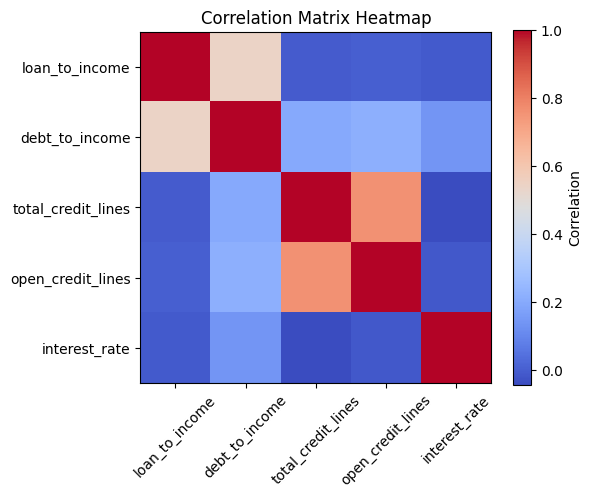

In [96]:
data_df["loan_amount"] = pd.to_numeric(data_df["loan_amount"], errors="coerce")
data_df["annual_income"] = pd.to_numeric(data_df["annual_income"], errors="coerce")
data_df["loan_to_income"] = data_df["loan_amount"] / data_df["annual_income"]

numeric_df = data_df[["loan_to_income", "debt_to_income", "total_credit_lines",
                      "open_credit_lines", "interest_rate"]].copy()

corr_matrix = numeric_df.corr()
plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()



The heatmap above shows correlations among five features: loan_to_income, debt_to_income, total_credit_lines, open_credit_lines, and interest_rate. Firstly, loan_to_income has a moderate positive correlation (~0.5) with debt_to_income, indicating that borrowers with higher debt relative to income also tend to have higher loan_to_income ratios. Secondly, total_credit_lines and open_credit_lines are strongly positively correlated (~0.8), which is expected since more total credit usually means more accounts are currently open. Thirdly, loan_to_income and interest_rate show a very weak negative correlation, suggesting that borrowers with higher loan-to-income ratios tend to have slightly lower interest rates. Lastly, debt_to_income has low correlations with other four features I consider adding. I think this show that these aspects are largely independent in this dataset.


Question 4:

<Figure size 1000x500 with 0 Axes>

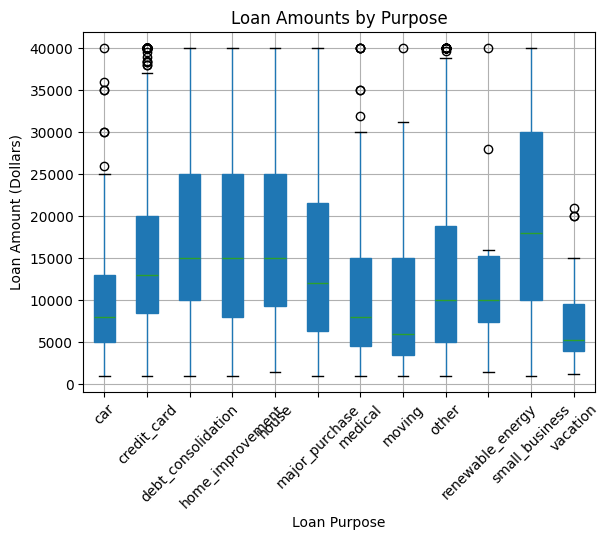

In [114]:
loan_df = data_df.dropna(subset=["loan_amount", "loan_purpose"])
plt.figure(figsize=(10,5))
loan_df.boxplot(column="loan_amount", by="loan_purpose", rot=45, patch_artist=True)
plt.title("Loan Amounts by Purpose")
plt.suptitle("")  
plt.xlabel("Loan Purpose")
plt.ylabel("Loan Amount (Dollars)")
plt.show()



For null values, I don't include the rows or columns that consists of the null value. Other than that, I think we could deal with null values by replace missing values with a typical number like the median so that the results can be the best accurate without changing the scale and variables dramatically.

This box and whisker plot shows the distribution of loan amounts for each loan purpose. The boxes represent the middle 50% of loan amounts, and the line inside each box indicating the median. Other than that, the whiskers show the typical range and the circles represent outliers. Loan purposes for home improvement, debt consolidation, and renewable energy seems to have higher median loan amounts. But car and vacation are the two smallest among all. Lastly, I noticed that several purposes, such as car, medical, and credit card, have notable high-value outliers, and those highlighting variability in loan sizes across different purposes.

Question 5:

In [112]:
import time

data = pd.read_csv("titanic.csv")

data["Age"] = data["Age"].fillna(data["Age"].median())
start_time = time.time()

data["age_bin_lambda"] = data["Age"].apply(
    lambda age: "Child" if age < 18 
                else
                "Young Adult" if age < 35 
                else
                "Adult" if age < 60 
                else
                "Senior"
)

time_lambda = time.time() - start_time
print(f"Lambda method time: {time_lambda:.6f} seconds")
start_time = time.time()

bins = [0, 18, 35, 60, 100]
labels = ["Child", "Young Adult", "Adult", "Senior"]
data["age_bin_cut"] = pd.cut(data["Age"], bins=bins, labels=labels, right=False)
time_cut = time.time() - start_time
print(f"pd.cut method time: {time_cut:.6f} seconds")
print(data[["Age", "age_bin_lambda", "age_bin_cut"]].head())



Lambda method time: 0.012000 seconds
pd.cut method time: 0.002233 seconds
    Age age_bin_lambda  age_bin_cut
0  22.0    Young Adult  Young Adult
1  38.0          Adult        Adult
2  26.0    Young Adult  Young Adult
3  35.0          Adult        Adult
4  35.0          Adult        Adult


Question 6:

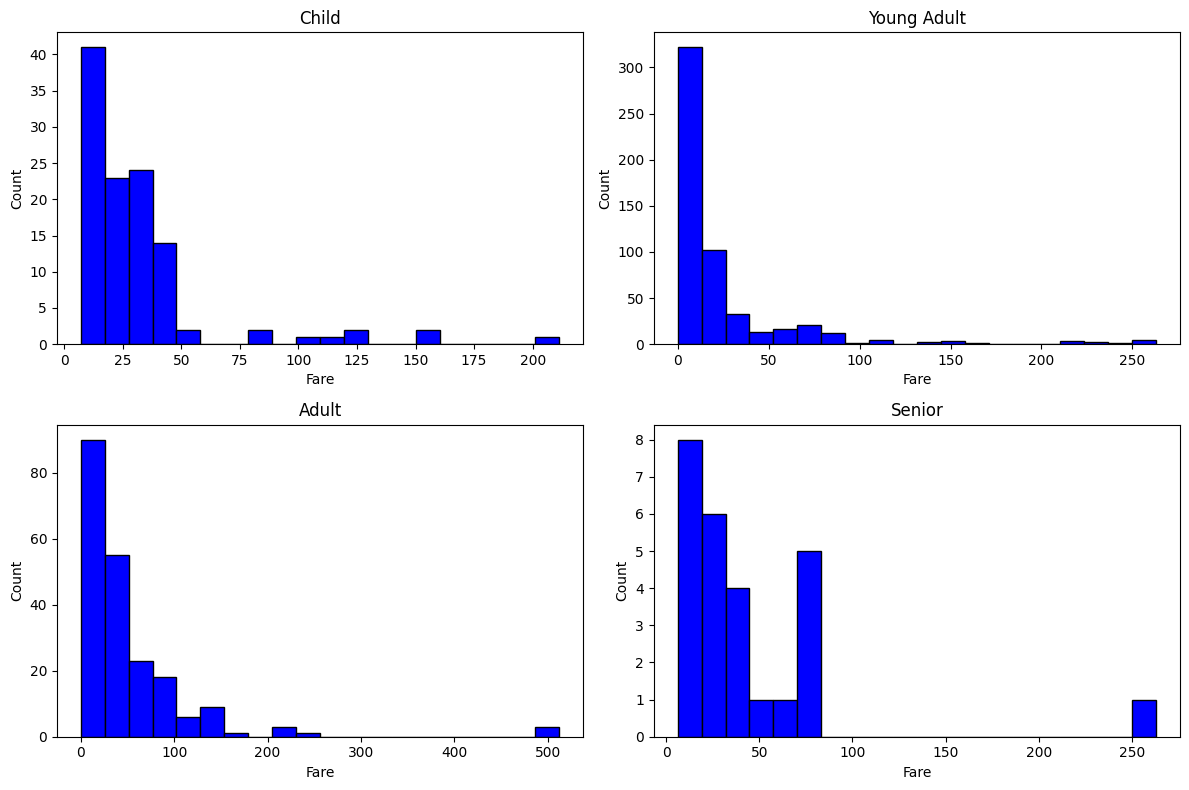

In [111]:
data["Age"] = data["Age"].fillna(data["Age"].median())

bins = [0, 18, 35, 60, 100]
labels = ["Child", "Young Adult", "Adult", "Senior"]
data["age_bin"] = pd.cut(data["Age"], bins=bins, labels=labels, right=False)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, label in enumerate(labels):
    subset = data[data["age_bin"] == label]
    axs[i].hist(subset["Fare"], bins=20, color="blue", edgecolor="black")
    axs[i].set_title(label)
    axs[i].set_xlabel("Fare")
    axs[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


The histograms show how Titanic fares different across different age groups. For children under 18, they will paid lower fares, and only a few are higher than others. For young adults from 18-34 have a wide range of fares, including many low-cost tickets and only some high fares. Adults from 35-39 years old also show a broad fare distribution, with more passengers paying medium to higher fares. This might be because this group may have had greater financial means or traveled in higher classes. Seniors with the age of 60+ tend to pay moderate fares, with fewer extreme values. I think this suggests this age group usually pays low to medium tickets. Most of the passengers pay low fares, only some of them are super high, this might be first class. But in general, these distributions have shown that age group partly showing the economic differences on Titanic.